# UCB vs EI: MCL1 MMGBSA

Compares UCB (Lower Confidence Bound) against Expected Improvement for the linear-empirical surrogate on MCL1 MMGBSA scores.

UCB formula: `LCB(x) = mean(x) - κ·std(x)`. Higher κ = more exploration.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': 16,
    "lines.linewidth": 2,
    "axes.labelsize": 18,
    "axes.titlesize": 22,
})

# Same color/style scheme as ProcessPlotter
_palette = sns.color_palette("tab20")
COLORS = {
    "ChemBERTa-2":       _palette[0],
    "MolFormer":         _palette[2],
    "Morgan Fingerprint": _palette[4],
}
STYLES = {
    "ChemBERTa-2":       "-",
    "MolFormer":         "--",
    "Morgan Fingerprint": ":",
}

In [ ]:
RUNS_DIR = Path("../bayesian_optimization_results")
K_RATIO = 0.01

KAPPAS = [0.5, 1.0, 2.0, 5.0]

# EI baseline: sequential runs used in the main comparison notebooks
EI_DB = "results/mcl1_mmpbsa_gb_proto_shuffled.sqlite"

In [3]:
dfs = []

# EI baseline
df_ei, top_k, source = load_data(EI_DB, k_ratio=K_RATIO)
df_ei = df_ei[df_ei["Surrogate"] == "Linear"]
df_ei["Label"] = "EI"
dfs.append(df_ei)

# UCB runs
for kappa in KAPPAS:
    db = RUNS_DIR / f"mcl1_mmgbsa_ucb_kappa{kappa}.sqlite"
    if not db.exists():
        print(f"Missing: {db}")
        continue
    df, top_k, source = load_data(str(db), k_ratio=K_RATIO)
    df["Label"] = f"UCB \u03ba={kappa}"
    dfs.append(df)

k = len(top_k)
data = pd.concat(dfs, ignore_index=True)
data["Scenario"] = "Sequential"  # all runs are sequential

labels_order = ["EI"] + [f"UCB \u03ba={k}" for k in KAPPAS]

print(f"Top-{K_RATIO*100:.0f}% threshold: {k} molecules")
print(f"Loaded {data['experiment_id'].nunique()} experiments, {len(data)} rows")
data[["Label", "Surrogate", "Embedding Model"]].drop_duplicates().sort_values("Label")

Top-1% threshold: 593 molecules
Loaded 6 experiments, 54015 rows


,Label,Surrogate,Embedding Model
0,EI,Linear,MolFormer
3601,EI,Linear,Morgan Fingerprint
7202,EI,Linear,ChemBERTa-2
10803,UCB κ=0.5,Linear,MolFormer
14404,UCB κ=0.5,Linear,Morgan Fingerprint
18005,UCB κ=0.5,Linear,ChemBERTa-2
21606,UCB κ=1.0,Linear,ChemBERTa-2
25207,UCB κ=1.0,Linear,MolFormer
28808,UCB κ=1.0,Linear,Morgan Fingerprint
32409,UCB κ=2.0,Linear,Morgan Fingerprint


## Top-1% Retrieval Curves

Each panel is one acquisition setting. Lines show cumulative fraction of top-1% molecules found vs. iteration,
colored by embedding model.

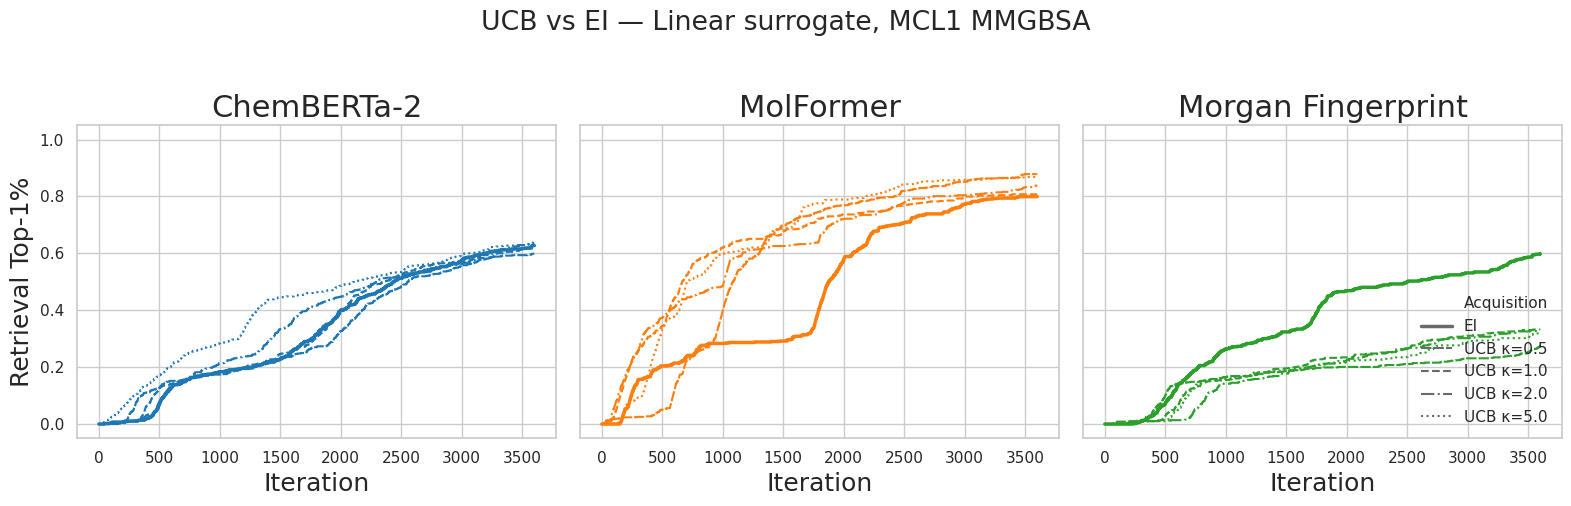

In [6]:
embedding_order = ["ChemBERTa-2", "MolFormer", "Morgan Fingerprint"]

# Linestyle encodes acquisition: EI = dashed baseline, UCB κ increases toward solid
label_style = {
    "EI":       ("-",        2.5),
    "UCB κ=0.5": ((0, (5, 1)), 1.5), # densely dashed
    "UCB κ=1.0": ("--",        1.5),
    "UCB κ=2.0": ("-.", 1.5),  
    "UCB κ=5.0": (":",         1.5),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, embedding in zip(axes, embedding_order):
    color = COLORS[embedding]
    for label in labels_order:
        group = data[(data["Label"] == label) & (data["Embedding Model"] == embedding)]
        if group.empty:
            continue
        y = group.groupby("Iteration")["is_top_k_cum"].max() / k
        ls, lw = label_style[label]
        ax.plot(y.index.values, y.values,
                color=color, linestyle=ls, linewidth=lw, label=label)
    ax.set_title(embedding)
    ax.set_xlabel("Iteration")
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel(f"Retrieval Top-{K_RATIO*100:.0f}%")

legend_elements = [mlines.Line2D([0], [0], color="none", label="Acquisition")]
for label in labels_order:
    ls, lw = label_style[label]
    legend_elements.append(
        mlines.Line2D([0], [0], color="dimgray", linestyle=ls, linewidth=lw, label=label)
    )
axes[-1].legend(handles=legend_elements, loc="lower right", frameon=False)

fig.suptitle("UCB vs EI \u2014 Linear surrogate, MCL1 MMGBSA", y=1.02)
plt.tight_layout()
plt.savefig("figures/ucb_vs_ei_mmgbsa.pdf", dpi=300, bbox_inches="tight")
plt.savefig("figures/ucb_vs_ei_mmgbsa.svg", dpi=300, bbox_inches="tight")
plt.show()


## Final Retrieval Rate (Summary Table)

In [5]:
embedding_order = ["ChemBERTa-2", "MolFormer", "Morgan Fingerprint"]

final = (
    data.groupby(["experiment_id", "Label", "Embedding Model"])["is_top_k"]
    .sum()
    .div(k)
    .reset_index()
    .rename(columns={"is_top_k": "Retrieval Rate"})
    .groupby(["Label", "Embedding Model"])["Retrieval Rate"]
    .mean()
    .unstack("Embedding Model")
    .reindex(labels_order)
    [embedding_order]
    .round(3)
)
final

Embedding Model,ChemBERTa-2,MolFormer,Morgan Fingerprint
Label,,,
EI,0.627,0.799,0.599
UCB κ=0.5,0.599,0.879,0.275
UCB κ=1.0,0.617,0.808,0.332
UCB κ=2.0,0.634,0.838,0.327
UCB κ=5.0,0.637,0.868,0.322
